In [1]:
# integration du notebook kaggle et aggregations avec les variables des autres fichiers

import os
import numpy as np
import pandas as pd
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt
import seaborn as sns

print(" Imports terminés")

 Imports terminés


In [2]:
# chargement des données depuis la racine du projet
data_dir = 'data/' 

# Chargement des fichiers principaux du kaggle
app_train = pd.read_csv(data_dir + 'application_train.csv')
app_test = pd.read_csv(data_dir + 'application_test.csv')

print(f"Train shape: {app_train.shape}")
print(f"Test shape: {app_test.shape}")

# Chargement des des autres fichiers (auxiliaires)
bureau = pd.read_csv(data_dir + 'bureau.csv')
bureau_balance = pd.read_csv(data_dir + 'bureau_balance.csv')
credit_card = pd.read_csv(data_dir + 'credit_card_balance.csv')
installments = pd.read_csv(data_dir + 'installments_payments.csv')
previous = pd.read_csv(data_dir + 'previous_application.csv')
pos_cash = pd.read_csv(data_dir + 'POS_CASH_balance.csv')

print("\n Tous les fichiers chargés")

Train shape: (307511, 122)
Test shape: (48744, 121)

 Tous les fichiers chargés


Distribution TARGET:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Taux de défaut: 8.07%


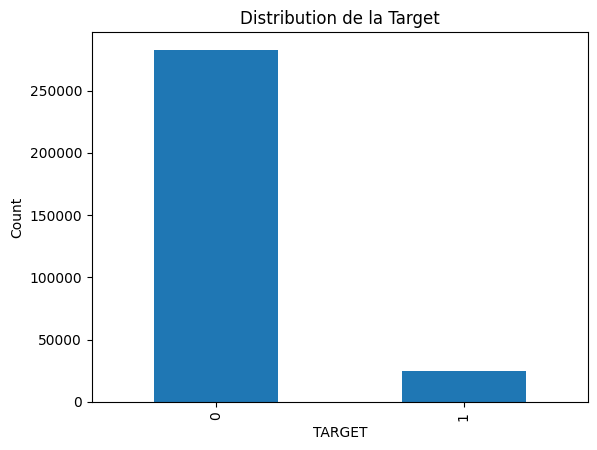

In [3]:
# feature engeneering du fichier kaggle
# Distribution de la target
print("Distribution TARGET:")
print(app_train['TARGET'].value_counts())
print(f"\nTaux de défaut: {app_train['TARGET'].mean():.2%}")

# Visualisation
app_train['TARGET'].value_counts().plot.bar()
plt.title('Distribution de la Target')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.show()

In [4]:
# Identifier et corriger les anomalies connues (du notebook Kaggle)
# DAYS_EMPLOYED avec des valeurs aberrantes

# Créer un flag pour les anomalies DAYS_EMPLOYED
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243

# Remplacer les anomalies par NaN
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
app_test['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

print(" Anomalies corrigées")

 Anomalies corrigées


In [5]:
# Features inspirées du notebook Kaggle

# Ratios de crédit
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']
app_test['CREDIT_INCOME_RATIO'] = app_test['AMT_CREDIT'] / app_test['AMT_INCOME_TOTAL']

app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_test['ANNUITY_INCOME_RATIO'] = app_test['AMT_ANNUITY'] / app_test['AMT_INCOME_TOTAL']

app_train['CREDIT_TERM'] = app_train['AMT_ANNUITY'] / app_train['AMT_CREDIT']
app_test['CREDIT_TERM'] = app_test['AMT_ANNUITY'] / app_test['AMT_CREDIT']

# Âge en années
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_test['DAYS_BIRTH'] = abs(app_test['DAYS_BIRTH'])

print(" Features créées")

 Features créées


In [6]:
# Aggregation bureau et bureau_balance
# One-Hot Encoding de STATUS dans bureau_balance
bureau_balance_ohe = pd.get_dummies(bureau_balance, columns=['STATUS'], prefix='BUREAU_BALANCE_STATUS')

# Agrégation par SK_ID_BUREAU
bureau_balance_agg = bureau_balance_ohe.groupby('SK_ID_BUREAU').agg(['mean', 'max', 'sum', 'size'])
bureau_balance_agg.columns = ['_'.join(col) for col in bureau_balance_agg.columns]
bureau_balance_agg.reset_index(inplace=True)

# Fusion bureau + bureau_balance_agg
bureau_fusion = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')

# One-Hot Encoding des variables catégorielles de bureau
cat_cols = ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
bureau_fusion = pd.get_dummies(bureau_fusion, columns=cat_cols, drop_first=True)

# Agrégation finale par SK_ID_CURR
bureau_agg = bureau_fusion.groupby('SK_ID_CURR').agg(['mean', 'min', 'max', 'sum'])
bureau_agg.columns = ['bureau_' + '_'.join(col).upper() for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

print(f" Bureau agrégé: {bureau_agg.shape}")
gc.collect()

 Bureau agrégé: (305811, 277)


C:\Users\chris\AppData\Local\Temp\ipykernel_18600\290915369.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bureau_agg.reset_index(inplace=True)


0

In [7]:
# Aggrégation Credit CARD - Agrégation par SK_ID_PREV
credit_card_agg = credit_card.groupby('SK_ID_PREV').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    'AMT_BALANCE': ['mean', 'max', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],
    'AMT_DRAWINGS_ATM_CURRENT': ['mean', 'sum'],
    'AMT_DRAWINGS_CURRENT': ['mean', 'sum'],
    'AMT_DRAWINGS_POS_CURRENT': ['mean', 'sum'],
    'AMT_PAYMENT_CURRENT': ['mean', 'sum'],
    'CNT_DRAWINGS_ATM_CURRENT': ['mean', 'sum'],
    'CNT_DRAWINGS_CURRENT': ['mean', 'sum'],
    'SK_DPD': ['mean', 'max', 'sum'],
    'SK_DPD_DEF': ['mean', 'max', 'sum']
})
credit_card_agg.columns = ['CC_' + '_'.join(col).upper() for col in credit_card_agg.columns]
credit_card_agg['CC_COUNT_RECORDS'] = credit_card.groupby('SK_ID_PREV').size()
credit_card_agg.reset_index(inplace=True)

# Récupérer SK_ID_CURR
credit_card_client = credit_card[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates()
credit_card_client = credit_card_client.merge(credit_card_agg, on='SK_ID_PREV', how='left')

print(f" Credit card agrégé par crédit: {credit_card_client.shape}")

 Credit card agrégé par crédit: (104307, 29)


In [8]:
# INSTALLMENTS - Agrégation par SK_ID_PREV
installments['PAYMENT_DIFF'] = installments['AMT_PAYMENT'] - installments['AMT_INSTALMENT']
installments['PAYMENT_RATIO'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + 1)
installments['DAYS_PAST_DUE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['LATE_PAYMENT'] = (installments['DAYS_PAST_DUE'] > 0).astype(int)

installments_agg = installments.groupby('SK_ID_PREV').agg({
    'NUM_INSTALMENT_VERSION': ['max'],
    'NUM_INSTALMENT_NUMBER': ['max'],
    'AMT_INSTALMENT': ['mean', 'sum'],
    'AMT_PAYMENT': ['mean', 'sum'],
    'PAYMENT_DIFF': ['mean', 'min', 'max'],
    'PAYMENT_RATIO': ['mean', 'min', 'max'],
    'DAYS_PAST_DUE': ['mean', 'max', 'sum'],
    'LATE_PAYMENT': ['sum', 'mean']
})
installments_agg.columns = ['INSTAL_' + '_'.join(col).upper() for col in installments_agg.columns]
installments_agg['INSTAL_COUNT'] = installments.groupby('SK_ID_PREV').size()
installments_agg.reset_index(inplace=True)

print(f" Installments agrégé par crédit: {installments_agg.shape}")

 Installments agrégé par crédit: (997752, 19)


In [9]:
# FUSION Credit Card + Installments au niveau SK_ID_PREV
credit_prev_merged = credit_card_client.merge(
    installments_agg,
    on='SK_ID_PREV',
    how='outer'
)

# AGRÉGATION FINALE par client (SK_ID_CURR)
credit_client_final = credit_prev_merged.drop('SK_ID_PREV', axis=1).groupby('SK_ID_CURR').agg(['mean', 'max', 'min', 'sum'])
credit_client_final.columns = ['CREDIT_' + '_'.join(col).upper() for col in credit_client_final.columns]
credit_client_final.reset_index(inplace=True)

print(f" Credit+Installments agrégé par client: {credit_client_final.shape}")
gc.collect()

 Credit+Installments agrégé par client: (103558, 181)


0

In [11]:
# Aggrégation Previous Application - Agrégation par SK_ID_CURR

# Features numériques à agréger
num_aggregations = {
    'AMT_ANNUITY': ['min', 'max', 'mean'],
    'AMT_APPLICATION': ['min', 'max', 'mean'],
    'AMT_CREDIT': ['min', 'max', 'mean'],
    'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
    'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
    'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['mean', 'sum'],
}

# Variables catégorielles à encoder
cat_cols_prev = ['NAME_CONTRACT_STATUS', 'NAME_CONTRACT_TYPE', 'CHANNEL_TYPE',
                 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
                 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
                 'NAME_PRODUCT_TYPE', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']

# One-Hot Encoding
previous_ohe = pd.get_dummies(previous, columns=cat_cols_prev, drop_first=False)


# Agrégation en une seule fois pour les numériques et les OneHot:
# les noms de colonnes sont automatiquement bien formatés

# Préparer le dictionnaire d'agrégation complet
agg_dict = num_aggregations.copy()

# Pour les colonnes OneHot, ajouter au dictionnaire
ohe_cols = [col for col in previous_ohe.columns if col.startswith(tuple(cat_cols_prev))]
for col in ohe_cols:
    agg_dict[col] = ['mean', 'sum']

# Agrégation en une seule fois
prev_agg = previous_ohe.groupby('SK_ID_CURR').agg(agg_dict)

# Aplatir les noms de colonnes
prev_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_agg.columns]
prev_agg.reset_index(inplace=True)

print(f" Previous application agrégé: {prev_agg.shape}")
gc.collect()

C:\Users\chris\AppData\Local\Temp\ipykernel_18600\956021056.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prev_agg.reset_index(inplace=True)


 Previous application agrégé: (338857, 223)


0

In [12]:
# Aggrégation POS_CASH - Agrégation par SK_ID_CURR
# One-Hot Encoding du statut
pos_cash = pd.get_dummies(pos_cash, columns=['NAME_CONTRACT_STATUS'], prefix='STATUS')

# Agrégation directe par client
pos_agg = pos_cash.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    'CNT_INSTALMENT': ['mean', 'max', 'sum'],
    'CNT_INSTALMENT_FUTURE': ['mean', 'min', 'sum'],
    'SK_DPD': ['mean', 'max', 'sum'],
    'SK_DPD_DEF': ['mean', 'max', 'sum'],
    'STATUS_Amortized debt': 'sum',
    'STATUS_Completed': 'sum',
    'STATUS_Demand': 'sum',
    'STATUS_Returned to the store': 'sum',
    'STATUS_Signed': 'sum',
    'STATUS_XNA': 'sum',
})

pos_agg.columns = ['POS_' + '_'.join(col).upper() if isinstance(col, tuple) else 'POS_' + col.upper() 
                   for col in pos_agg.columns]
pos_agg.reset_index(inplace=True)

# Ratio de retards
pos_agg['POS_DPD_RATIO'] = pos_agg['POS_SK_DPD_SUM'] / (pos_agg['POS_MONTHS_BALANCE_SIZE'] + 1)

print(f" POS_CASH agrégé: {pos_agg.shape}")
gc.collect()

 POS_CASH agrégé: (337252, 23)


0

In [13]:
# Fusion progressive de toute les tables sur SK_ID_CURR
print("Début de la fusion...")

# Partir de app_train
train = app_train.copy()
test = app_test.copy()

print(f"Train initial: {train.shape}")

# Fusion avec Bureau
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')
test = test.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(f"Après bureau: {train.shape}")

# Fusion avec Credit Card + Installments
train = train.merge(credit_client_final, on='SK_ID_CURR', how='left')
test = test.merge(credit_client_final, on='SK_ID_CURR', how='left')
print(f"Après credit+installments: {train.shape}")

# Fusion avec Previous Application
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')
test = test.merge(prev_agg, on='SK_ID_CURR', how='left')
print(f"Après previous: {train.shape}")

# Fusion avec POS_CASH
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')
test = test.merge(pos_agg, on='SK_ID_CURR', how='left')
print(f"Après POS_CASH: {train.shape}")

print("\n Toutes les fusions terminées ")
print(f"\n Shape finale TRAIN: {train.shape}")
print(f" Shape finale TEST: {test.shape}")

Début de la fusion...
Train initial: (307511, 126)
Après bureau: (307511, 402)
Après credit+installments: (307511, 582)
Après previous: (307511, 804)
Après POS_CASH: (307511, 826)

 Toutes les fusions terminées 

 Shape finale TRAIN: (307511, 826)
 Shape finale TEST: (48744, 825)


In [16]:
# Encodage des variables categorielles

# Identifier les colonnes catégorielles restantes
categorical_columns = train.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles à encoder: {len(categorical_columns)}")

# Label Encoding pour les colonnes avec 2 catégories
le = LabelEncoder()
le_count = 0

for col in categorical_columns:
    if train[col].nunique() <= 2:
        # Convertir en string pour uniformiser
        train[col] = train[col].fillna('Missing').astype(str)
        test[col] = test[col].fillna('Missing').astype(str)
        
        # Fit sur train + test combinés pour éviter les valeurs inconnues
        # le test set contient des valeurs qui n'existent pas dans le train set
        combined_values = pd.concat([train[col], test[col]], axis=0)
        le.fit(combined_values)
        
        # Transform
        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])
        le_count += 1

print(f"Label encoded: {le_count} colonnes")

# One-Hot Encoding pour les autres
train = pd.get_dummies(train)
test = pd.get_dummies(test)

print(f" Après encodage - Train: {train.shape}, Test: {test.shape}")

Colonnes catégorielles à encoder: 67
Label encoded: 39 colonnes
✅ Après encodage - Train: (307511, 2569), Test: (48744, 2194)


In [17]:
# Aligner les colonnes de train et test
# S'assurer que train et test ont les mêmes colonnes
train_labels = train['TARGET']
train = train.drop(columns=['TARGET'])

# Aligner les colonnes
train, test = train.align(test, join='inner', axis=1)

# Remettre la target
train['TARGET'] = train_labels

print(f" Colonnes alignées - Train: {train.shape}, Test: {test.shape}")
print(f"\n Nombre total de features: {train.shape[1] - 1}")

 Colonnes alignées - Train: (307511, 2032), Test: (48744, 2031)

 Nombre total de features: 2031


In [18]:
# Vérification des valeurs manquantes
# Taux de valeurs manquantes
missing_train = (train.isnull().sum() / len(train)).sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

print(f"Colonnes avec valeurs manquantes: {len(missing_train)}")
print("\nTop 10 colonnes avec le plus de NaN:")
print(missing_train.head(10))

# Supprimer les colonnes avec > 75% de NaN
threshold = 0.75
cols_to_drop = missing_train[missing_train > threshold].index.tolist()
print(f"\nColonnes à supprimer (>{threshold*100}% NaN): {len(cols_to_drop)}")

if len(cols_to_drop) > 0:
    train = train.drop(columns=cols_to_drop)
    test = test.drop(columns=cols_to_drop)
    print(f" Après suppression - Train: {train.shape}, Test: {test.shape}")

Colonnes avec valeurs manquantes: 692

Top 10 colonnes avec le plus de NaN:
CREDIT_CC_AMT_PAYMENT_CURRENT_MEAN_MEAN    0.801438
CREDIT_CC_AMT_PAYMENT_CURRENT_MEAN_MIN     0.801438
CREDIT_CC_AMT_PAYMENT_CURRENT_MEAN_MAX     0.801438
CREDIT_INSTAL_PAYMENT_DIFF_MIN_MEAN        0.801324
CREDIT_INSTAL_PAYMENT_DIFF_MAX_MIN         0.801324
CREDIT_INSTAL_DAYS_PAST_DUE_MAX_MIN        0.801324
CREDIT_INSTAL_PAYMENT_DIFF_MAX_MAX         0.801324
CREDIT_INSTAL_PAYMENT_DIFF_MAX_MEAN        0.801324
CREDIT_INSTAL_PAYMENT_DIFF_MEAN_MAX        0.801324
CREDIT_INSTAL_AMT_PAYMENT_MEAN_MEAN        0.801324
dtype: float64

Colonnes à supprimer (>75.0% NaN): 66
 Après suppression - Train: (307511, 1966), Test: (48744, 1965)


In [ ]:
# suppression des colonnes constantes
constant_cols = [col for col in train.columns 
                 if train[col].nunique() <= 1]

train.drop(columns=constant_cols, inplace=True)
test.drop(columns=constant_cols, inplace=True)

Top 15 features positivement corrélées avec TARGET:
TARGET                                         1.000000
CREDIT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_SUM    0.116543
bureau_DAYS_CREDIT_MEAN                        0.089729
CREDIT_CC_AMT_BALANCE_MEAN_SUM                 0.087657
CREDIT_CC_AMT_BALANCE_MEAN_MAX                 0.087617
CREDIT_CC_AMT_BALANCE_MEAN_MEAN                0.087365
CREDIT_CC_AMT_BALANCE_MEAN_MIN                 0.086997
CREDIT_CC_CNT_DRAWINGS_CURRENT_MEAN_MEAN       0.082580
CREDIT_CC_CNT_DRAWINGS_CURRENT_MEAN_MAX        0.082576
CREDIT_CC_CNT_DRAWINGS_CURRENT_MEAN_SUM        0.082496
CREDIT_CC_CNT_DRAWINGS_CURRENT_MEAN_MIN        0.082292
CREDIT_INSTAL_LATE_PAYMENT_MEAN_SUM            0.079327
PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN         0.077671
bureau_MONTHS_BALANCE_MEAN_MEAN                0.076424
bureau_DAYS_CREDIT_MIN                         0.075248
Name: TARGET, dtype: float64

Top 15 features négativement corrélées avec TARGET:
bureau_BUREAU_BALANCE_STAT

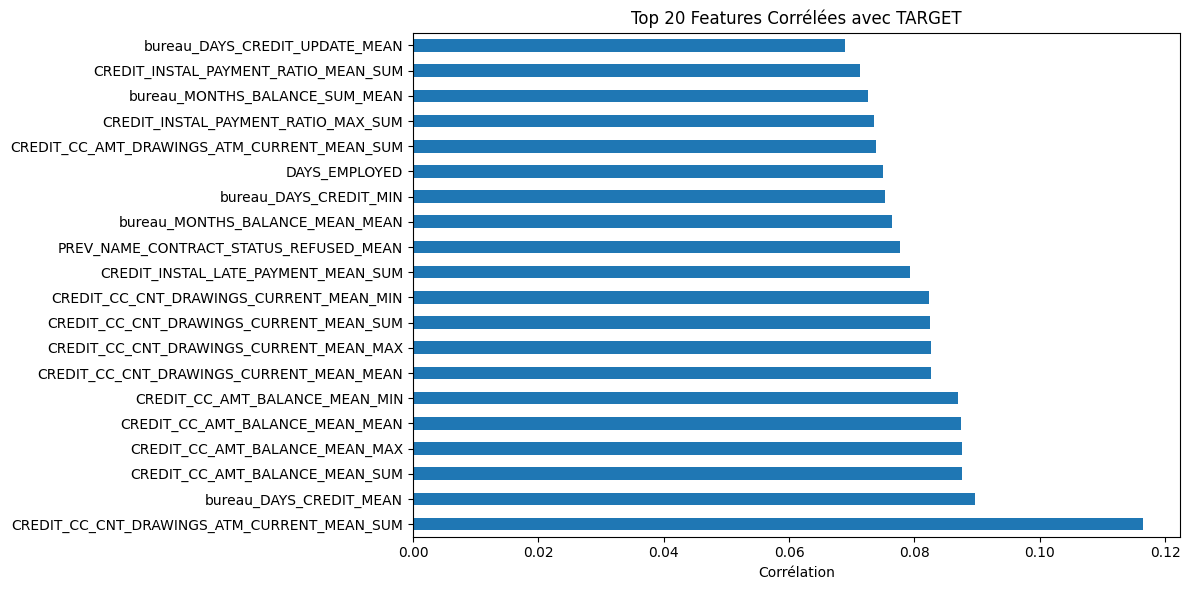

In [19]:
# Calculer les corrélations avec la TARGET
correlations = train.corr()['TARGET'].sort_values(ascending=False)

print("Top 15 features positivement corrélées avec TARGET:")
print(correlations.head(15))

print("\nTop 15 features négativement corrélées avec TARGET:")
print(correlations.tail(15))

# Visualisation
plt.figure(figsize=(12, 6))
correlations.drop('TARGET').head(20).plot.barh()
plt.title('Top 20 Features Corrélées avec TARGET')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.show()

In [20]:
# suppression des colonnes constantes
constant_cols = [col for col in train.columns 
                 if train[col].nunique() <= 1]

train.drop(columns=constant_cols, inplace=True)
test.drop(columns=constant_cols, inplace=True)

In [22]:
# Séparer features X et target y
X = train.drop(columns=['TARGET', 'SK_ID_CURR'])
y = train['TARGET']
X_test = test.drop(columns=['SK_ID_CURR'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

# Imputation des NaN restants
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("\n Données prêtes pour la modélisation")

X shape: (307511, 1961)
y shape: (307511,)
X_test shape: (48744, 1961)


MemoryError: Unable to allocate 4.49 GiB for an array with shape (1961, 307511) and data type float64

In [ ]:
# Regression logistique simple
# Validation croisée simple
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)

# CV Score
cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring='roc_auc')
print(f"Logistic Regression - ROC AUC CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Entraînement sur tout le dataset
log_reg.fit(X, y)
predictions_lr = log_reg.predict_proba(X_test)[:, 1]

print(" Logistic Regression entraînée")

In [ ]:
# Random Forest rapide
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)

# CV Score
cv_scores_rf = cross_val_score(rf, X, y, cv=3, scoring='roc_auc')
print(f"Random Forest - ROC AUC CV: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Entraînement
rf.fit(X, y)
predictions_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest entraîné")

In [ ]:
# Feature importances de Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(feature_importance.head(20))

# Visualisation
plt.figure(figsize=(12, 8))
feature_importance.head(30).plot.barh(x='feature', y='importance')
plt.title('Top 30 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Sauvegarder les datasets finaux
train.to_csv('train_final.csv', index=False)
test.to_csv('test_final.csv', index=False)

# Sauvegarder les prédictions
submission_lr = pd.DataFrame({
    'SK_ID_CURR': test['SK_ID_CURR'],
    'TARGET': predictions_lr
})
submission_lr.to_csv('submission_logistic.csv', index=False)

submission_rf = pd.DataFrame({
    'SK_ID_CURR': test['SK_ID_CURR'],
    'TARGET': predictions_rf
})
submission_rf.to_csv('submission_random_forest.csv', index=False)

print(" Fichiers sauvegardés:")
print("  - train_final.csv")
print("  - test_final.csv")
print("  - submission_logistic.csv")
print("  - submission_random_forest.csv")

In [ ]:
# Résumé du pipeline
print("RÉSUMÉ DU PIPELINE")
print(f"  - Train: {train.shape[0]} lignes x {train.shape[1]} colonnes")
print(f"  - Test: {test.shape[0]} lignes x {test.shape[1]} colonnes")
print(f"  - Features: {train.shape[1] - 2} (sans SK_ID_CURR et TARGET)")

print(f"\n Sources de données intégrées:")
print(f"  - application_train/test")
print(f"  - bureau + bureau_balance → {bureau_agg.shape[1]-1} features")
print(f"  - credit_card + installments → {credit_client_final.shape[1]-1} features")
print(f"  - previous_application → {prev_agg.shape[1]-1} features")
print(f"  - POS_CASH_balance → {pos_agg.shape[1]-1} features")

print(f"\n Performances:")
print(f"  - Logistic Regression: ROC AUC = {cv_scores.mean():.4f}")
print(f"  - Random Forest: ROC AUC = {cv_scores_rf.mean():.4f}")

print("\n Pipeline terminé")